# Accessing research-quality sea level data

Authors: Nikos Kalligeris, Marinos Charalampakis, Stijn Vermaere, Dias Bakeev, Bart Vanhoorne, Tjess Hernandez 

Description: 
This notebook page breaks down a sample script in Python for accessing research-quality sea level data through the new SLSMF API (https://api.ioc-sealevelmonitoring.org/v2/doc). The user can save the notebook locally, modify the inputs and visualise the output sea level timeseries. 

Python scripts for accessing the sea level data for selected examples can be found in the folder named *Examples*.

## 1. Configuration of the notebook

In [65]:
import sys
print(sys.executable)

!{sys.executable} -m pip install requests pandas numpy matplotlib seaborn python-dotenv plotly

/opt/conda/bin/python


In [66]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
from datetime import datetime
import time
from io import StringIO
import ipywidgets as widgets
from dotenv import load_dotenv


In [67]:
load_dotenv('./env')

True

## 2. User input

Enter your unique *api_key* to be able to access new SLSMF API for downloading research-quality sea level data.

Instructions on obtaining an *api_key* can be found in the *API_description.md* document. 

In [68]:
APIKEY = widgets.Text(
    value=os.getenv('API_KEY'),
    placeholder='Type something',
    description='APIKEY:',
    disabled=False   
)
APIKEY

bd423717a30e8414189510b75eb36655049d3e1341d86b9b99e83eec2210534ea6f5bd4ecf37f447ec41588f12c1cb871bc6669dfaef758c213e6b522a078d47


Text(value='bd423717a30e8414189510b75eb36655049d3e1341d86b9b99e83eec2210534ea6f5bd4ecf37f447ec41588f12c1cb871b…

Enter the station ID information in the code below. 
-  For the *station_ID* option below, the user can either use the IOC station code, or the SSC ID from the SLSMF catalogue: https://www.ioc-sealevelmonitoring.org/ssc/ . Using the SSC code will allow to identify the preferred sensor for the user-defined dates, for the seal level stations for which multiple sensors are attached to a single SSC code. 
-  For the *sensor* option below, the user can choose whether to harvest data from one ('one-sensor' option) or multiple ('alternate-sensor') sensors. In the case 'one-sensor' is chosen, the API will return data from only one sensor type for the entire period. The selected sensor will be the one that was preferred on the most days during the requested period, filtered by the included sensors parameter. If 'alternate-sensor' is chosen, the API will return data from multiple sensors. The preferred sensor **for each individual day** will be returned, filtered by the included sensors parameter. If no preferred sensor is available on a given day, no data will be returned for that day.
-  For the *includesensors* option below, the user can specify one or more sensors to harvest sea level data from. In combination with the above options, if 'one-sensor' is used and a single sensor is specified in the *includesensors*, the procedure for identifying a preferred sensor for the dates specified is not followed. If more than one sensors are specified in *includesensors*, then the procedure for identifying the preferred sensor will be followed as explained in the above bullet, but restricted to the sensors specified in the *includesensors* field. If *includesensors* is left blank (empty list as []), the code will use all available sensors for the user-defined SSC-ID.

The available *includesensor* options and their interpretation is expained in the *API_description.md* document. To check which sensor(s) are available for a station or site, the users can go to the Catalogue tab on the SLSMF page (https://www.ioc-sealevelmonitoring.org/ssc/), find the SSC-ID on the left column, and then click on the 'detail' button on the right column. The available sensors will appear in the right column of the table in the 'Linked codes' section.

In [69]:
# user inputs for station ID and sensor
station_ID = 'adak'
includesensors = ['wls']

station = widgets.Text(
    value='adak',
    placeholder='IOC code',
    description='IOC:',
    disabled=False   
)
sensor = widgets.Dropdown(
    options=['one-sensor', 'alternate-sensor'],
    description='sensor',
    disabled=False,
    value='one-sensor'
)
start_date=widgets.DatePicker(
    description='start_date',
    disabled=False,
    value=datetime.strptime('01/01/2025', '%m/%d/%Y')
)

end_date=widgets.DatePicker(
    description='end_date',
    disabled=False,
    value=datetime.strptime('02/01/2025', '%m/%d/%Y')
)

days_per_page = widgets.BoundedIntText(
    min=1,
    max=365,
    value=15,
    description='days per page',
    disabled=False   
)
includesensors = widgets.SelectMultiple(
    options=['rad', 'prs', 'prt', 'prte', 'wls'],
    value=['wls'],
    #rows=10,
    description='includesensors',
    disabled=False
)

from ipywidgets import Box

display(station, includesensors, sensor, start_date, end_date, days_per_page)

Text(value='adak', description='IOC:', placeholder='IOC code')

SelectMultiple(description='includesensors', index=(4,), options=('rad', 'prs', 'prt', 'prte', 'wls'), value=(…

Dropdown(description='sensor', options=('one-sensor', 'alternate-sensor'), value='one-sensor')

DatePicker(value=datetime.datetime(2025, 1, 1, 0, 0), description='start_date', step=1)

DatePicker(value=datetime.datetime(2025, 2, 1, 0, 0), description='end_date', step=1)

BoundedIntText(value=15, description='days per page', max=365, min=1)

In the following fields, enter the starting and ending day for requesting research-quality sea level data in the format YYYY-MM-DD.
- The *start_date* marks the beginning of the time period for which data is being requested, marking the initial date of the desired data range (this date is included in the results).
- The *end_date* is the last date of the time period for which data is being requested, marking the final date in the specified data range (this date is not included in the results). When the Timestop equals the current date, real time data will be added for the current day. The data will be from the sensor which was selected the most as preferred during the whole period, taking the include sensors field into account.

The *days_per_page* field allows the user to restrict the number of days spanning a page in order to reduce the file size per request, with a maximum of 365 days. 
-  In case *days_per_page* is higher or equal to the days of sea level data requested, a single request will be made to the API server and all data will be downloaded in one page.
-  Otherwise, the sea level data will be requested in chunks of data restricted to a length equal to *days_per_page* - note that if data gaps exist for a station, days with no data do not count in the *days_per_page*, and therefore it may exceed the time period defined by *days_per_page* in terms of dates.

The user inputs below control the relative sea level mean, the output time vector and format of output file. 
- *subtract_30d_average*: when set to *true*, the requested data will be recalculated in reference to the mean sea level of the last ~30 days.
- *flag_qc*: when set to *true*, includes qc flags as extra fields of booleans (T or F).
- *fit_to_sample_rate*: set to *false* to obtain the data at the specific rate or frequency defined by the station. This means that
the data will be provided according to the station's predefined sampling rates. Setting it to *true* organizes the data into predefined time slots based on the transmission rate, essentially normalizing the data to ensure it aligns with the established intervals. Missing but expected records are added with columns slevel = NA and missing = T. This process adjusts the data to fit consistent, standardized time periods, ensuring that it is uniformly distributed according to the rate at which it was transmitted or recorded.
- *media_type*: choose the format in which you would like the requested data to be delivered. Two choices are available: receive the data in text (CSV) format, where values are separated by commas, or in JSON format, which is a structured data format commonly used for representing information in key-value pairs. If *media_type* is left empty, default is 'text/csv'.

In [70]:
# user inputs for station ID and sensor

subtract_30d_average = widgets.Dropdown(
    options=['false', 'true'],
    description='subtract_30d_average',
    disabled=False,
    value='false'
)
fit_to_sample_rate = widgets.Dropdown(
    options=['false', 'true'],
    description='fit_to_sample_rate',
    disabled=False,
    value='false'
)
flag_qc = widgets.Dropdown(
    options=['false', 'true'],
    description='flag_qc',
    disabled=False,
    value='true'
)
media_type = widgets.Dropdown(
    options=['application/json', 'text/csv'],
    description='media_type',
    disabled=False,
    value='application/json'
)

from ipywidgets import Box

display(subtract_30d_average, fit_to_sample_rate, flag_qc, media_type)

Dropdown(description='subtract_30d_average', options=('false', 'true'), value='false')

Dropdown(description='fit_to_sample_rate', options=('false', 'true'), value='false')

Dropdown(description='flag_qc', index=1, options=('false', 'true'), value='true')

Dropdown(description='media_type', options=('application/json', 'text/csv'), value='application/json')

The user inputs below, provided in the form of true/false flags, control the individual quality control tools employed by the new SLSMF API. The user needs to set all tool flags to be employed in the post-processing to *true*, and all the others to *false*. Filters never remove entire records. They only remove the sea level value by setting the slevel column to NA. Set *flag_qc* to *true* to see based on which qc parameter this happened. The corresponding qc flag will have as value T.
- *filter_out_of_range*: when set to *true*, this filter sets slevel to NA for points that are significantly higher or lower than the majority of the values within a specified time period. It is designed to identify and remove outliers or anomalies, ensuring that the remaining data more accurately represents typical trends and patterns for that particular time frame.
- *filter_exceeded_neighbours*: when set to *true*, this filter works by comparing the difference between adjacent sea level data points. If the difference between a specific data point and its neighboring values exceeds a defined threshold, the slevel is set to NA for that data point. This helps eliminate abrupt, unusual fluctuations that may not align with the general trend of the surrounding data. Caution should be exercised when using this filter for tsunami events, as the initial tsunami signal may be incorrectly identified as an outlier due to exceeding the neighboring data points.
- *filter_spikes_via_median*: when set to *true*, this filter sets slevel to NA for data points that deviate substantially from a spline-fit curve, which is a smooth, flexible curve that models the underlying trend of the data. By identifying and removing sea levels that significantly differ from this curve, the filter helps to retain only those sea levels that are consistent with the overall trend, improving the accuracy and reliability of the dataset.
- *filter_flat_line*: when set to *true*, this filter addresses data gaps that appear as flat, unchanging segments in the data diagrams, typically indicating periods where no data was recorded or the data was unavailable. By removing these flat-line sections, the filter helps to clean the dataset, ensuring that only continuous, meaningful data is retained for analysis and that gaps in the data do not distort the overall trends or patterns.
- *filter_completeness*: when set to *true*, this filter sets slevel to NA for days with low completeness. A day is flagged when its sum of records is less than 30% of the expected amount, based on specific rate or frequency defined by the station.
- *filter_distinctness*: when set to *true*, this filter sets slevel to NA for days with low distinctness. A day is flagged when it contains less than 10% distinct sea levels, where 100% would be in case every sea level value is unique.
- *filter_shift*: when set to *true*, this filter sets slevel to NA for days with a vertical shift. A day is flagged when the median sea level of the day is outside the 0.1 and 0.9 quantile range of the sea levels in the previous month or until last shift.

A guiding document describing the quality control steps employed by the new SLSMF API service can be found in the *research_data* folder.

In [71]:
# user inputs for station ID and sensor
filter_out_of_range = widgets.Dropdown(
    options=['false', 'true'],
    description='out_of_range',
    disabled=False,
    value='false'
)
filter_exceeded_neighbours = widgets.Dropdown(
    options=['false', 'true'],
    description='exceeded_neighbours',
    disabled=False,
    value='false'
)
filter_spikes_via_median = widgets.Dropdown(
    options=['false', 'true'],
    description='spikes_via_median',
    disabled=False,
    value='false'
)
filter_flat_line = widgets.Dropdown(
    options=['false', 'true'],
    description='flat_line',
    disabled=False,
    value='false'
)
filter_completeness = widgets.Dropdown(
    options=['false', 'true'],
    description='completeness',
    disabled=False,
    value='false'
)
filter_distinctness = widgets.Dropdown(
    options=['false', 'true'],
    description='distinctness',
    disabled=False,
    value='false'
)
filter_shift = widgets.Dropdown(
    options=['false', 'true'],
    description='shift',
    disabled=False,
    value='false'
)

from ipywidgets import Box

display(filter_out_of_range, filter_exceeded_neighbours, filter_spikes_via_median, filter_flat_line, filter_completeness, filter_distinctness, filter_shift)

Dropdown(description='out_of_range', options=('false', 'true'), value='false')

Dropdown(description='exceeded_neighbours', options=('false', 'true'), value='false')

Dropdown(description='spikes_via_median', options=('false', 'true'), value='false')

Dropdown(description='flat_line', options=('false', 'true'), value='false')

Dropdown(description='completeness', options=('false', 'true'), value='false')

Dropdown(description='distinctness', options=('false', 'true'), value='false')

Dropdown(description='shift', options=('false', 'true'), value='false')

## 3. Data download

The code below is used in Python to download the requested sea level data based on the above user inputs. The code reads the downloaded data in variable named *S* before plotting.

In [74]:
def fetch_research_data():
    """
    Download and read research-quality sea level data from SLSMF API
    Returns a pandas DataFrame with the sea level data
    """
    
    api_url = 'https://api.ioc-sealevelmonitoring.org/v2/research/stations/'
    
    # Calculate number of days and pages
    no_of_days = (end_date.value - start_date.value).days
    no_of_pages = int(np.ceil(no_of_days / days_per_page.value))
    
    # Initialize empty list to store dataframes
    dataframes = []
    
    print(f"Downloading {no_of_pages} pages of data in {media_type.value} format...")
    
    # Loop to download data
    for i in range(1, no_of_pages + 1):
        page = i  # current page number requested
      
        # Building the custom URL
        url = f"{api_url}{station.value}/sensors/{sensor.value}/data"
        params = {
            'days_per_page': days_per_page.value,
            'page': page,
            'timestart': start_date.value.strftime("%Y-%m-%d"),
            'timestop': end_date.value.strftime("%Y-%m-%d"),
            'subtract_30d_average': subtract_30d_average.value,
            'fit_to_sample_rate': fit_to_sample_rate.value,
            'flag_qc': flag_qc.value,
            'filter_out_of_range': filter_out_of_range.value,
            'filter_exceeded_neighbours': filter_exceeded_neighbours.value,
            'filter_spikes_via_median': filter_spikes_via_median.value,
            'filter_flat_line': filter_flat_line.value,
            'filter_completeness': filter_completeness.value,
            'filter_distinctness': filter_distinctness.value,
            'filter_shift': filter_shift.value
        }
        
        # Add includesensors if specified
        if includesensors:
            for s in includesensors.value:
                params['includesensors[]'] = s
      
        # Downloading the data
        print(f'Downloading page {page} / {no_of_pages} of the data requested in {media_type.value} format')
        headers = {
            'X-Api-Key': APIKEY.value,
            'Accept': media_type.value
        }
        
        response = requests.get(url, params=params, headers=headers)
        
        if response.status_code != 200:
            raise Exception(f"API Error {response.status_code}: {response.text}")
      
        response_text = response.text
      
        if media_type.value == 'application/json':
            data = response.json()
            if 'data' in data:
                tmp = pd.DataFrame(data['data'])
                # Convert stime to datetime
                tmp['stime'] = pd.to_datetime(tmp['stime'], utc=True)
            else:
                tmp = pd.DataFrame()
        else:
            # CSV handling
            tmp = pd.read_csv(StringIO(response_text), skiprows=2)
        
        if not tmp.empty:
            dataframes.append(tmp)
      
        # Rate limiting (1 second delay)
        time.sleep(1)
    
    # Combine all dataframes
    if not dataframes:
        raise Exception("No sea level data retrieved.")
    
    S = pd.concat(dataframes, ignore_index=True)

    
    return S

In [75]:
sealevel_with_flags = fetch_research_data()

Uncomment the line below to save the sea level data to a CSV file.

In [76]:
# Save to CSV
# sealevel_with_flags.to_csv('SLSMF_tg_data_fit_to_sample_rate.csv', index=False)

## 4. Data plotting

The code below is used in Python to plot the requested sea level data based on the above user inputs. The plot of the downloaded sea level time series should appear below the code.

In [77]:
def plot(S):
    S['slevel'] = pd.to_numeric(S['slevel'], errors='coerce')
    S.dropna(inplace=True)
    # Set plot style
    sns.set(style="whitegrid")
    plt.rcParams['figure.figsize'] = (12, 6)
    
    # plot the data
    plt.figure(figsize=(14, 7))
    
    # Plot the S.stime and S.slevel
    plt.plot(S['stime'], S['slevel'], color='black', linewidth=1.5, label='Sea Level')
    
    # Add legend and labels
    plt.title(f'data for SLSMF station ID = {station_ID}', fontsize=14, fontweight='bold')
    plt.xlabel('date', fontsize=12)
    plt.ylabel('WL (m)', fontsize=12)
    
    # Enable grid
    plt.grid(True, alpha=0.3)
    plt.gca().xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y-%m-%d'))
    plt.gcf().autofmt_xdate()
    plt.legend(loc='best')
    
    plt.tight_layout()
    plt.show()

### 4.1 static raw and filtered plot

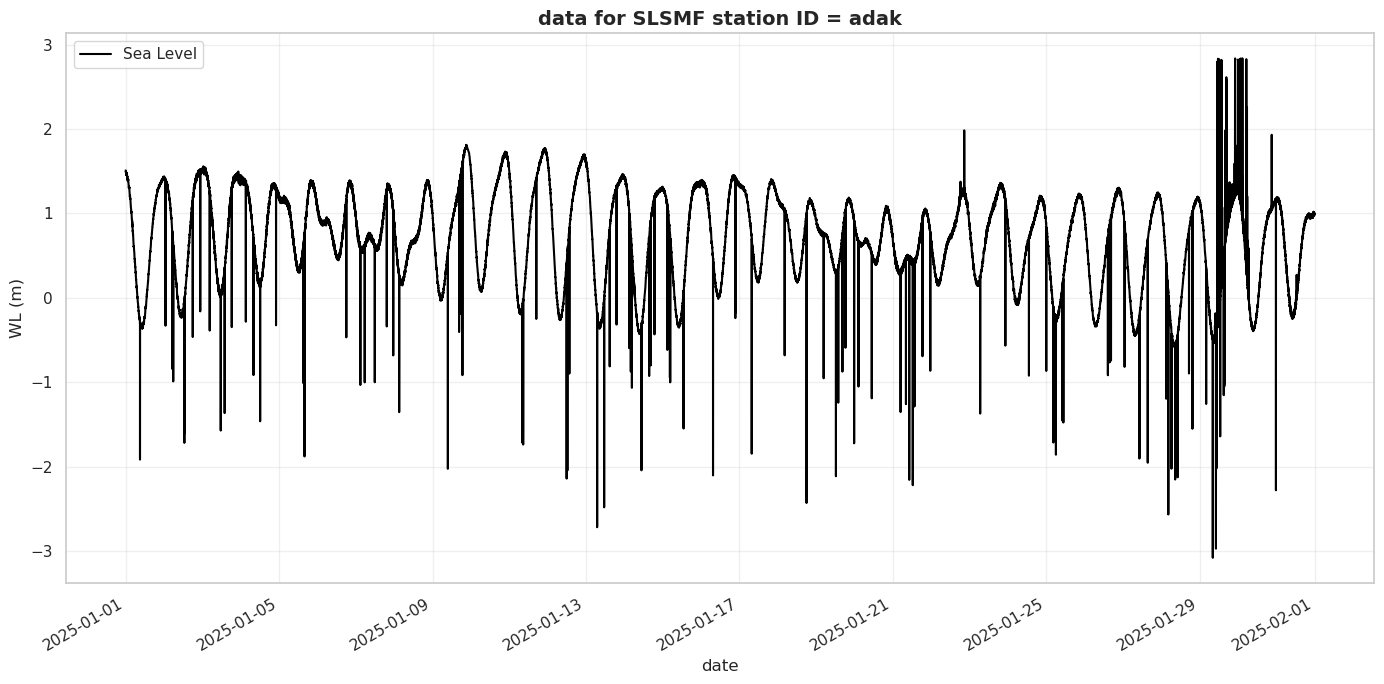

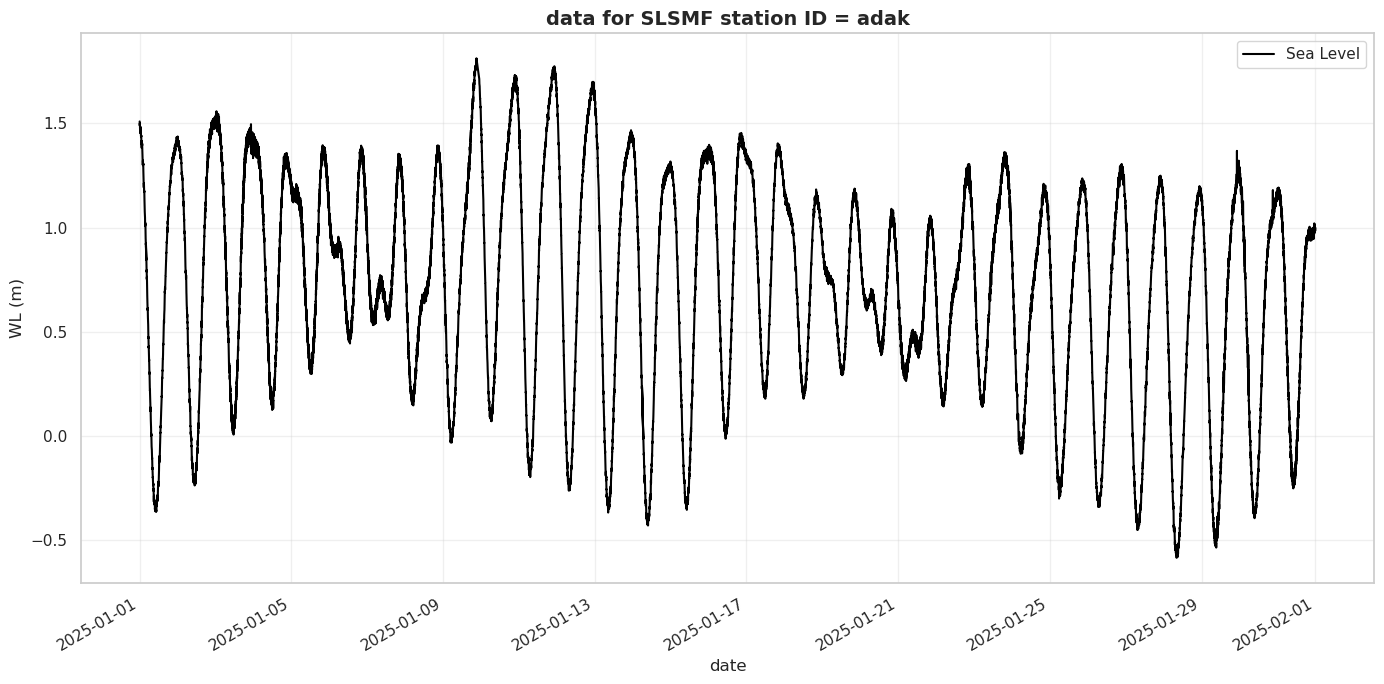

In [78]:
plot(sealevel_with_flags)
sealevel_qc = sealevel_with_flags[sealevel_with_flags.missing == 'F']
sealevel_qc = sealevel_qc[sealevel_qc.out_of_range == 'F']
sealevel_qc = sealevel_qc[sealevel_qc.exceeded_neighbours == 'F']
sealevel_qc = sealevel_qc[sealevel_qc.spikes_via_median == 'F']
sealevel_qc = sealevel_qc[sealevel_qc.flat_line == 'F']
sealevel_qc = sealevel_qc[sealevel_qc.completeness == 'F']
sealevel_qc = sealevel_qc[sealevel_qc.distinctness == 'F']

plot(sealevel_qc)

### 4.2 Interactive plot

In [79]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from typing import List, Optional
import plotly.io as pio

def plot_sea_level_with_qc(
    df: pd.DataFrame,
    slevel_col: str = 'slevel',
    time_col: str = 'stime',
    qc_columns: List[str] = None,
    export_path: Optional[str] = None,
):
    """
    Plot sea level data with QC flags.
    Clicking a QC flag in the legend hides BOTH the markers AND the sea level values at those points.
    Expects QC flags to be 'Y' (Yes/True) or 'F' (False).
    """
    
    # Default QC columns if not specified
    if qc_columns is None:
        qc_columns = [
            'out_of_range', 'spikes_via_median', 
            'exceeded_neighbours', 'flat_line', 
            'distinctness', 'completeness', 'shift', 'missing'
        ]
    
    # Filter to only existing QC columns
    qc_columns = [col for col in qc_columns if col in df.columns]
    
    # Make a copy to avoid modifying the original dataframe
    df_plot = df.copy()
    
    # Convert time column to datetime if needed
    if not pd.api.types.is_datetime64_any_dtype(df_plot[time_col]):
        df_plot[time_col] = pd.to_datetime(df_plot[time_col])
    
    # Convert 'NA' strings to NaN for slevel
    df_plot[slevel_col] = pd.to_numeric(df_plot[slevel_col], errors='coerce')
    
    # Sort by time
    df_plot = df_plot.sort_values(time_col).reset_index(drop=True)
    
    # ===== CREATE CLEAN BASE LINE =====
    # Replace slevel with NaN wherever ANY QC flag is 'Y'
    df_plot['slevel_clean'] = df_plot[slevel_col].copy()
    any_flag_mask = pd.Series(False, index=df_plot.index)
    for qc_col in qc_columns:
        any_flag_mask = any_flag_mask | (df_plot[qc_col] == 'T')
    df_plot.loc[any_flag_mask, 'slevel_clean'] = np.nan
    
    # Color mapping for QC flags
    colors = {
        'out_of_range': 'red',
        'spikes_via_median': 'orange',
        'exceeded_neighbours': 'purple',
        'flat_line': 'brown',
        'distinctness': 'pink',
        'completeness': 'cyan',
        'shift': 'green',
        'missing': 'gray'
    }
    
    # ===== BUILD FIGURE =====
    fig = go.Figure()
    
    # 1. Clean base line (gaps where QC flags are raised)
    fig.add_trace(go.Scatter(
        x=df_plot[time_col],
        y=df_plot['slevel_clean'],
        mode='lines',
        name='Sea Level (clean)',
        line=dict(color='black', width=1.5),
        hovertemplate='<b>%{x|%Y-%m-%d %H:%M}</b><br>WL: %{y:.3f} m<extra></extra>',
        legendgroup='clean'
    ))
    
    # 2. For each QC flag, add a LINE trace + MARKER trace (linked by legendgroup)
    for qc_col in qc_columns:
        qc_mask = df_plot[qc_col] == 'T'
        
        if qc_mask.any():
            color = colors.get(qc_col, 'blue')
            label = qc_col.replace('_', ' ').title()
            
            # Line trace showing the actual values at flagged points
            fig.add_trace(go.Scatter(
                x=df_plot.loc[qc_mask, time_col],
                y=df_plot.loc[qc_mask, slevel_col],
                mode='markers',
                name=f'{label} (value)',
                line=dict(color=color, width=1.5),
                hovertemplate=f'<b>{qc_col}</b><br>%{{x|%Y-%m-%d %H:%M}}<br>WL: %{{y:.3f}} m<extra></extra>',
                legendgroup=qc_col,
                showlegend=False  # Don't show separately in legend
            ))
            
            # Marker trace for the flag
            fig.add_trace(go.Scatter(
                x=df_plot.loc[qc_mask, time_col],
                y=df_plot.loc[qc_mask, slevel_col],
                mode='markers',
                name=label,
                marker=dict(
                    color=color,
                    size=8,
                    symbol='circle-open',
                    line=dict(width=2, color=color)
                ),
                hovertemplate=f'<b>{qc_col}</b><br>%{{x|%Y-%m-%d %H:%M}}<br>WL: %{{y:.3f}} m<extra></extra>',
                legendgroup=qc_col
            ))
    
    # Determine station name
    station_name = "Unknown"
    if "sensor" in df_plot.columns:
        station_name = df_plot["sensor"].iloc[0]
    elif "_sensor_id" in df_plot.columns:
        station_name = df_plot["_sensor_id"].iloc[0]

    # Layout
    fig.update_layout(
        title=f'Sea Level Data with QC Flags - Station: {station_name}',
        xaxis_title='Date/Time',
        yaxis_title='Water Level (m)',
        hovermode='x unified',
        legend=dict(
            orientation='h',
            yanchor='bottom',
            y=1.02,
            xanchor='right',
            x=1
        ),
        template='plotly_white',
        height=600
    )
    
    fig.update_xaxes(
        tickformat='%Y-%m-%d %H:%M',
        tickangle=-45
    )
    
    if export_path:
        html_path = export_path.replace('.png', '.html')
        fig.write_html(html_path)
        print(f"Saved HTML: {html_path}")
        try:
            fig.write_image(export_path)
            print(f"Saved Image: {export_path}")
        except Exception as e:
            print(f"Could not save PNG (install kaleido): {e}")

    pio.renderers.default = "notebook" 
    fig.show(mode="notebook")


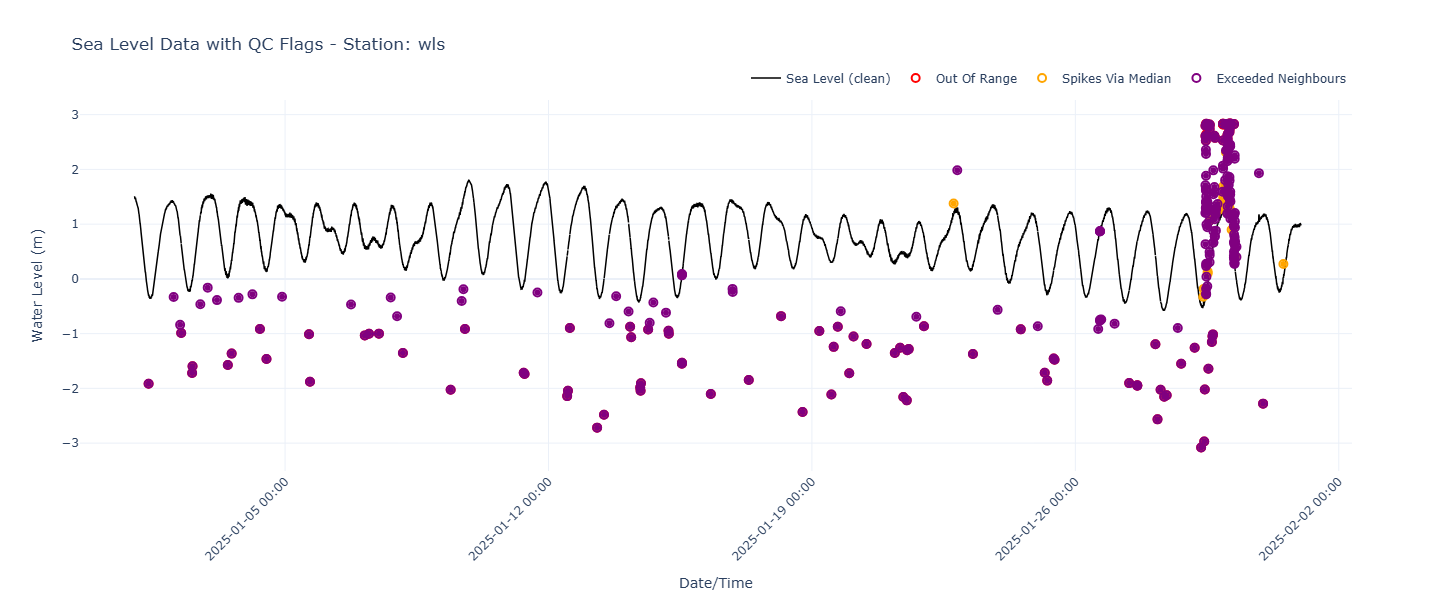

In [80]:

# ===== USAGE =====
plot_sea_level_with_qc(
    df=sealevel_with_flags,
    slevel_col='slevel',
    time_col='stime',
    qc_columns=[
        'out_of_range', 'spikes_via_median', 
        'exceeded_neighbours', 'flat_line', 
        'distinctness', 'completeness', 'shift', 'missing'
    ]
)